#  Customer Sales Data Cleaning and Preprocessing

### Internship Task 1

**Name:** Nilakshi

**Role:** Data Analyst Intern

**Tools Used:** Python, Pandas, NumPy, Matplotlib

---

 ## Project Objective

The objective of this project is to clean and preprocess the Customer Sales dataset by identifying and handling missing values, removing duplicate records, standardizing text values, correcting data types, formatting dates, and preparing the dataset for further analysis.

The final output is a clean and structured dataset that can be used for data analysis and visualization.

#  Import Required Libraries

In this section, the required Python libraries are imported.

- **Pandas** is used for data manipulation and analysis.
- **NumPy** is used for numerical operations.
- **Matplotlib** is used for data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset

The raw dataset is loaded into a Pandas DataFrame for further inspection and cleaning.

In [40]:
df = pd.read_csv("../data/customer_sales_raw.csv")

# 👀 Display First Five Rows

The `head()` function is used to display the first five rows of the dataset.

This helps in understanding the structure of the dataset and the available columns.

In [22]:
df.head()

,customer_id,customer_name,age,gender,country,email,join_date,total_purchase_usd,rating,segment
0,1168,Customer_1168,74,Male,UK,customer_1168@mail.com,30-05-2020,3067.26,3,Standard
1,1231,Customer_1231,47,Other,UK,customer_1231@mail.com,19-01-2020,2867.84,1,Standard
2,1026,Customer_1026,47,Female,Unknown,customer_1026@mail.com,07-05-2022,4536.09,2,Premium
3,1064,Customer_1064,52,Other,Canada,customer_1064@mail.com,22-12-2021,3299.83,1,Premium
4,1010,Customer_1010,46,Female,India,customer_1010@mail.com,22-09-2022,1212.43,2,Basic


# 👀 Display Last Five Rows

The `tail()` function is used to display the last five rows of the dataset.

This helps verify that the dataset has been loaded correctly.

In [23]:
df.tail()

,customer_id,customer_name,age,gender,country,email,join_date,total_purchase_usd,rating,segment
288,1189,Customer_1189,60,Female,Germany,customer_1189@mail.com,15-12-2020,4650.31,3,Premium
289,1072,Customer_1072,37,Male,Germany,customer_1072@mail.com,27-07-2024,2626.68,4,Premium
290,1107,Customer_1107,24,Female,Germany,customer_1107@mail.com,31-12-2023,3174.27,1,Standard
291,1271,Customer_1271,46,Female,India,customer_1271@mail.com,21-03-2022,4125.99,3,Standard
292,1103,Customer_1103,64,Female,Germany,customer_1103@mail.com,17-06-2021,1168.40,4,Standard


# 📐 Dataset Shape

The `shape` attribute returns the number of rows and columns present in the dataset.

This provides an overview of the dataset size before cleaning.

In [24]:
df.shape

(293, 10)

# 🏷️ Column Names

The column names are displayed to understand the available features in the dataset.

This also helps identify columns that may require renaming during preprocessing.

In [25]:
df.columns

Index(['customer_id', 'customer_name', 'age', 'gender', 'country', 'email',
       'join_date', 'total_purchase_usd', 'rating', 'segment'],
      dtype='str')

# ℹ️ Dataset Information

The `info()` function provides detailed information about the dataset.

It includes:

- Number of rows
- Number of columns
- Data types
- Non-null values
- Memory usage

This information helps identify missing values and incorrect data types.

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         293 non-null    int64  
 1   customer_name       293 non-null    str    
 2   age                 293 non-null    int64  
 3   gender              293 non-null    str    
 4   country             293 non-null    str    
 5   email               293 non-null    str    
 6   join_date           293 non-null    str    
 7   total_purchase_usd  293 non-null    float64
 8   rating              293 non-null    int64  
 9   segment             293 non-null    str    
dtypes: float64(1), int64(3), str(6)
memory usage: 23.0 KB


# 📊 Statistical Summary

The `describe()` function generates descriptive statistics for all numerical columns.

It provides information such as:

- Count
- Mean
- Standard Deviation
- Minimum Value
- Maximum Value
- Quartiles

This helps understand the distribution of numerical data.

In [27]:
df.describe()

,customer_id,age,total_purchase_usd,rating
count,293.000000,293.000000,293.000000,293.000000
mean,1149.890785,47.143345,2485.431809,2.358362
std,86.616350,16.225506,1365.529302,1.511794
min,1001.000000,18.000000,32.210000,1.000000
25%,1076.000000,34.000000,1387.050000,1.000000
50%,1150.000000,47.000000,2484.050000,2.000000
75%,1224.000000,60.000000,3678.710000,4.000000
max,1300.000000,75.000000,4959.270000,5.000000


# 🔍 Initial Observations

Based on the initial exploration:

- The dataset has been loaded successfully.
- The structure of the dataset has been examined.
- Column names have been identified.
- Data types have been inspected.
- Numerical statistics have been reviewed.

The next step is to perform detailed data profiling before cleaning the dataset.

# 🔍 Data Profiling

## What is Data Profiling?

Data profiling is the process of examining the dataset to understand its structure, quality, and content before performing data cleaning.

It helps identify:
- Missing values
- Duplicate records
- Unique values
- Data types
- Inconsistent data
- Data quality issues

This step is very important because it helps decide the appropriate data cleaning techniques.

# 📌 Missing Values Analysis

Missing values are empty or null entries in a dataset.

Before handling them, it is important to identify which columns contain missing values and how many missing values are present.

In [29]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values

Series([], dtype: int64)

#  Missing Value Percentage

Calculating the percentage of missing values helps determine whether missing data should be removed or imputed.

In [30]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False)

Series([], dtype: float64)

#  Duplicate Record Analysis

Duplicate records reduce data quality and may produce incorrect analytical results.

The following step checks whether duplicate rows exist in the dataset.

In [31]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


#  Data Types

Understanding data types is essential because numerical, categorical, and datetime columns require different preprocessing techniques.

In [32]:
df.dtypes

customer_id             int64
customer_name             str
age                     int64
gender                    str
country                   str
email                     str
join_date                 str
total_purchase_usd    float64
rating                  int64
segment                   str
dtype: object

Count Data Types

In [33]:
df.dtypes.value_counts()

str        6
int64      3
float64    1
Name: count, dtype: int64

#  Unique Values

Checking unique values helps identify inconsistent text values, spelling mistakes, and unexpected categories.

In [34]:
df.nunique()

customer_id           293
customer_name         293
age                    58
gender                  4
country                 6
email                 293
join_date             267
total_purchase_usd    275
rating                  5
segment                 3
dtype: int64

#  Memory Usage

Checking memory usage helps understand the size of the dataset and resource utilization.

In [35]:
df.memory_usage(deep=True)

Index                   132
customer_id            2344
customer_name         18166
age                    2344
gender                15882
country               15738
email                 20803
join_date             17287
total_purchase_usd     2344
rating                 2344
segment               16382
dtype: int64

# Summary Table

In [36]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

summary

,Data Type,Missing Values,Unique Values
customer_id,int64,0,293
customer_name,str,0,293
age,int64,0,58
gender,str,0,4
country,str,0,6
email,str,0,293
join_date,str,0,267
total_purchase_usd,float64,0,275
rating,int64,0,5
segment,str,0,3


#  Initial Observations

After profiling the dataset, the following observations were made:

- The dataset structure was examined successfully.
- Missing values were identified.
- Duplicate records were checked.
- Data types were reviewed.
- Unique values were analyzed.
- A detailed summary of the dataset was generated.

Based on these observations, the next step is to clean the dataset by handling missing values and duplicate records.

#  Missing Values Analysis

## Why Handle Missing Values?

Missing values can affect the quality of data analysis and machine learning models.

Before handling missing values, it is important to understand where they exist and choose the most appropriate technique to deal with them.

Common techniques include:

- Removing missing values
- Replacing with Mean
- Replacing with Median
- Replacing with Mode
- Replacing with a custom value

In [37]:
df.isnull().sum()

customer_id           0
customer_name         0
age                   0
gender                0
country               0
email                 0
join_date             0
total_purchase_usd    0
rating                0
segment               0
dtype: int64

## Observation

The dataset was checked for missing values using the `isnull().sum()` function.

No missing values were found in any of the columns.

Therefore, no missing value treatment was required, and the dataset was already complete in terms of missing data.

# 🛠 Missing Values Treatment

Since no missing values were found in the dataset, no missing value treatment was performed.

The dataset was already complete and ready for the next preprocessing step.

#  Duplicate Records Analysis

## Objective

Duplicate records reduce data quality and may lead to incorrect analytical results.

In this step, the dataset is checked for duplicate rows before removing them.

In [38]:
df.duplicated().sum()

np.int64(0)

#  Standardize Text Values

## Objective

The purpose of this step is to standardize text values by removing unnecessary spaces and ensuring consistent capitalization.

This improves data consistency and prevents duplicate categories caused by formatting differences.

Code 1

In [42]:
text_columns = ["customer_name", "gender", "country", "email", "segment"]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

### Apply Consistent Capitalization

To maintain consistency, text values are converted into a standard format.

# Code 2

In [43]:
df["customer_name"] = df["customer_name"].str.title()

df["gender"] = df["gender"].str.title()

df["country"] = df["country"].str.title()

df["segment"] = df["segment"].str.title()

df["email"] = df["email"].str.lower()

### Verification

The unique values of categorical columns were checked to ensure that text standardization was applied successfully.

In [44]:
print(df["gender"].unique())

print(df["country"].unique())

print(df["segment"].unique())

<StringArray>
['Male', 'Other', 'Female', 'Unknown']
Length: 4, dtype: str
<StringArray>
['Uk', 'Unknown', 'Canada', 'India', 'Usa', 'Germany']
Length: 6, dtype: str
<StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str


## Observation

The text values were standardized by removing extra spaces and applying consistent capitalization.

Email addresses were converted to lowercase to maintain consistency.

This improves the overall quality and readability of the dataset.

#  Date Formatting

## Objective

To ensure that date values are stored in a consistent datetime format for accurate filtering, sorting, and analysis.

# Code

In [45]:
df["join_date"] = pd.to_datetime(df["join_date"])

C:\Users\nilak\AppData\Local\Temp\ipykernel_30864\2254313651.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["join_date"] = pd.to_datetime(df["join_date"])


# Verify

In [46]:
df["join_date"].head()

0   2020-05-30
1   2020-01-19
2   2022-05-07
3   2021-12-22
4   2022-09-22
Name: join_date, dtype: datetime64[us]

## Observation

The join_date column was successfully converted into datetime format using the pandas `to_datetime()` function.

This ensures consistency and enables time-based analysis.

# 🏷 Rename Column Headers

## Objective

To make the column names clean, consistent, and easy to use by converting them to lowercase and replacing spaces with underscores.

# Code

In [47]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

# Verify

In [48]:
df.columns

Index(['customer_id', 'customer_name', 'age', 'gender', 'country', 'email',
       'join_date', 'total_purchase_usd', 'rating', 'segment'],
      dtype='str')

## Observation

The column names were reviewed and standardized.

The dataset now follows consistent naming conventions, making the code easier to read and maintain.

# 🔢 Data Type Conversion

## Objective

To verify that each column has the correct data type required for analysis and calculations.

In [49]:
df.dtypes

customer_id                    int64
customer_name                    str
age                            int64
gender                           str
country                          str
email                            str
join_date             datetime64[us]
total_purchase_usd           float64
rating                         int64
segment                          str
dtype: object

## Observation

The data types of all columns were verified.

The dataset contains appropriate data types for numerical, categorical, and datetime fields.

# 📊 Outlier Detection

## Objective

Outliers are extreme values that differ significantly from the rest of the data.

Detecting outliers helps identify unusual observations that may affect statistical analysis and machine learning models.

# Step 1: Select Numerical Columns

In [50]:
numerical_columns = ["age", "total_purchase_usd", "rating"]

numerical_columns

['age', 'total_purchase_usd', 'rating']

# Step 2: Boxplot

### Boxplot Visualization

Boxplots are used to identify potential outliers in numerical columns.

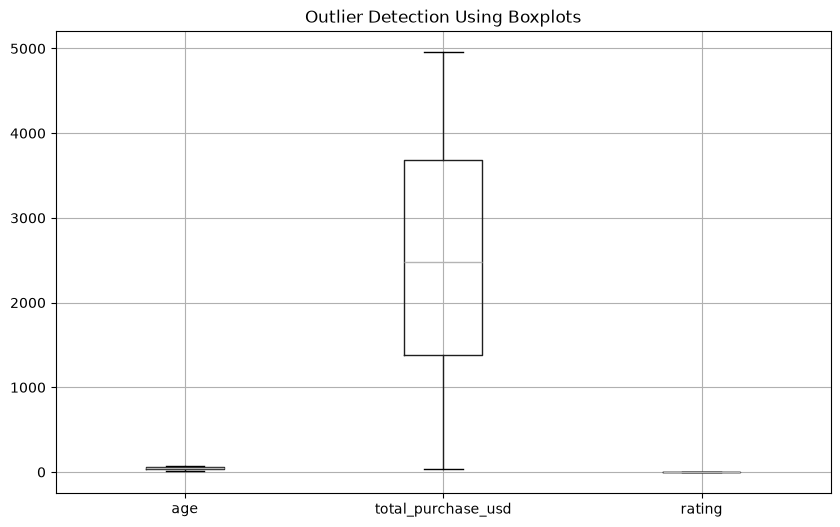

In [51]:
plt.figure(figsize=(10,6))

df.boxplot(column=numerical_columns)

plt.title("Outlier Detection Using Boxplots")

plt.show()

## Observation

The boxplots were examined to identify potential outliers in the numerical columns.

Any extreme values observed should be investigated further before performing advanced analysis or predictive modelling.

#  Data Validation

## Objective

The purpose of this step is to verify that the dataset is clean, consistent, and ready for analysis.

In [53]:
print("Missing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nData Types")
print(df.dtypes)

Missing Values
customer_id           0
customer_name         0
age                   0
gender                0
country               0
email                 0
join_date             0
total_purchase_usd    0
rating                0
segment               0
dtype: int64

Duplicate Rows
0

Data Types
customer_id                    int64
customer_name                    str
age                            int64
gender                           str
country                          str
email                            str
join_date             datetime64[us]
total_purchase_usd           float64
rating                         int64
segment                          str
dtype: object


## Observation

The final validation confirmed that:

- No missing values are present.
- No duplicate records exist.
- Data types are appropriate.
- Text values are standardized.
- The dataset is ready for further analysis.

# Save Clean Dataset

## Objective

The cleaned dataset is saved for future analysis and visualization.

In [55]:
df.to_csv("../outputs/customer_sales_cleaned.csv", index=False)

## Observation

The cleaned dataset was successfully saved in the outputs folder for future use.

# 📋 Project Summary

## Overview

This project focused on cleaning and preprocessing a customer sales dataset using Python and Pandas.

Several data quality checks were performed to ensure that the dataset is clean, consistent, and ready for analysis.

## Data Cleaning Tasks Performed

- Imported and explored the dataset.
- Performed data profiling.
- Checked for missing values.
- Checked for duplicate records.
- Standardized text values.
- Formatted date columns.
- Verified column names.
- Validated data types.
- Performed outlier detection.
- Validated the final dataset.
- Saved the cleaned dataset.

#  Project Conclusion

The customer sales dataset was successfully cleaned and validated.

The dataset was checked for missing values, duplicate records, inconsistent text formatting, data types, and outliers.

After completing all preprocessing steps, the dataset became clean, consistent, and ready for further analysis and visualization.

This project strengthened my understanding of data cleaning, preprocessing techniques, and the practical use of Python and Pandas in real-world data analysis.

#  Future Improvements

In future versions of this project, the following improvements can be implemented:

- Advanced outlier treatment using the IQR method.
- Data visualization using Seaborn and Plotly.
- Exploratory Data Analysis (EDA).
- Interactive dashboards using Power BI.
- Machine Learning models for customer segmentation and prediction.

#  Skills Learned

During this project, I learned:

- Data Cleaning
- Data Profiling
- Missing Value Analysis
- Duplicate Detection
- Text Standardization
- Date Formatting
- Data Validation
- Data Type Handling
- Outlier Detection
- Python Programming
- Pandas Library
- Data Preprocessing

# ✅ Final Checklist

| Task | Status |
|------|--------|
| Dataset Loaded | ✅ |
| Data Profiling | ✅ |
| Missing Values Checked | ✅ |
| Duplicate Records Checked | ✅ |
| Text Standardization | ✅ |
| Date Formatting | ✅ |
| Column Validation | ✅ |
| Data Type Validation | ✅ |
| Outlier Detection | ✅ |
| Dataset Saved | ✅ |

# 🙏 Thank You

Thank you for reviewing this project.

This notebook demonstrates the complete data cleaning and preprocessing workflow performed on a customer sales dataset using Python and Pandas.

In [56]:
df.to_csv("../outputs/customer_sales_cleaned.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
